In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# visual theme for standard charts
sns.set_theme(style="whitegrid")
print("All analysis and visualization tools are loaded.")

All analysis and visualization tools are loaded.


In [3]:
# 1. Loading most relevant dataset (given up to Nov 2020)
file_path = "Dataset/Unemployment_Rate_upto_11_2020.csv"
unemp_df = pd.read_csv(file_path)

# 2. Removing hidden spaces from the column headers
unemp_df.columns = unemp_df.columns.str.strip()

print("Data loaded successfully! Here is a view of few:")
display(unemp_df.head())

Data loaded successfully! Here is a view of few:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [4]:
# 1. Dropping empty rows
unemp_df = unemp_df.dropna()

# 2. Rename columns to short and easy to use
unemp_df = unemp_df.rename(columns={
    'Region': 'State',
    'Region.1': 'Area', # North, South, East, West
    'Estimated Unemployment Rate (%)': 'Unemp_Rate',
    'Estimated Employed': 'Employed_Count',
    'Estimated Labour Participation Rate (%)': 'Labour_Part_Rate'
})

# 3. Converting 'Date' to proper date-time format
unemp_df['Date'] = pd.to_datetime(unemp_df['Date'].str.strip(), format='%d-%m-%Y')

# 4. Extract just the month for specific monthly analysis
unemp_df['Month'] = unemp_df['Date'].dt.month_name()

print("Data cleaned. New column names:")
print(unemp_df.columns.tolist())

Data cleaned. New column names:
['State', 'Date', 'Frequency', 'Unemp_Rate', 'Employed_Count', 'Labour_Part_Rate', 'Area', 'longitude', 'latitude', 'Month']


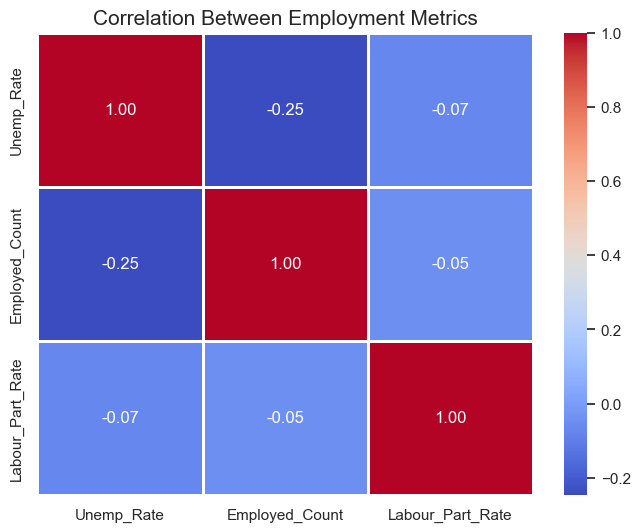

In [5]:
plt.figure(figsize=(8, 6))

# Calculated the correlation matrix (only on the number columns)
num_cols = unemp_df[['Unemp_Rate', 'Employed_Count', 'Labour_Part_Rate']]
calc_corr = num_cols.corr()

# Drawing the heatmap
sns.heatmap(calc_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title("Correlation Between Employment Metrics", fontsize=15)
plt.show()

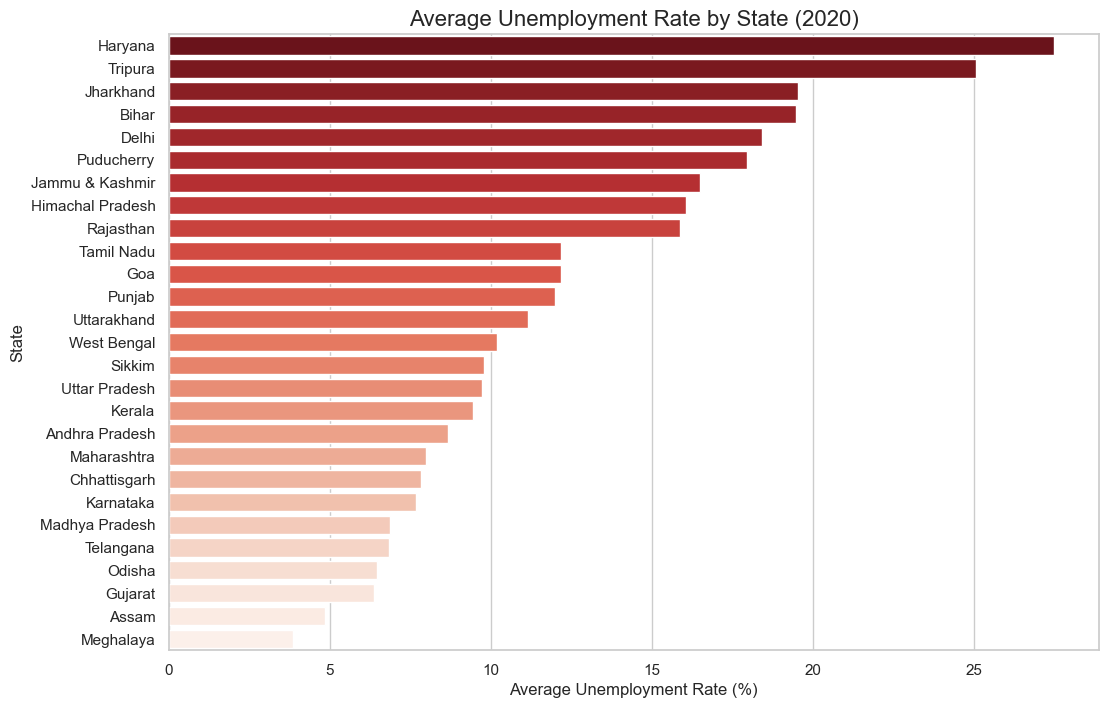

In [6]:
plt.figure(figsize=(12, 8))

# Calculated average unemployment per state and organized them.
state_avg = unemp_df.groupby('State')['Unemp_Rate'].mean().sort_values(ascending=False).reset_index()

# Created bar chart
sns.barplot(data=state_avg, x='Unemp_Rate', y='State', palette='Reds_r', hue='State', legend=False)

plt.title("Average Unemployment Rate by State (2020)", fontsize=16)
plt.xlabel("Average Unemployment Rate (%)", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.show()

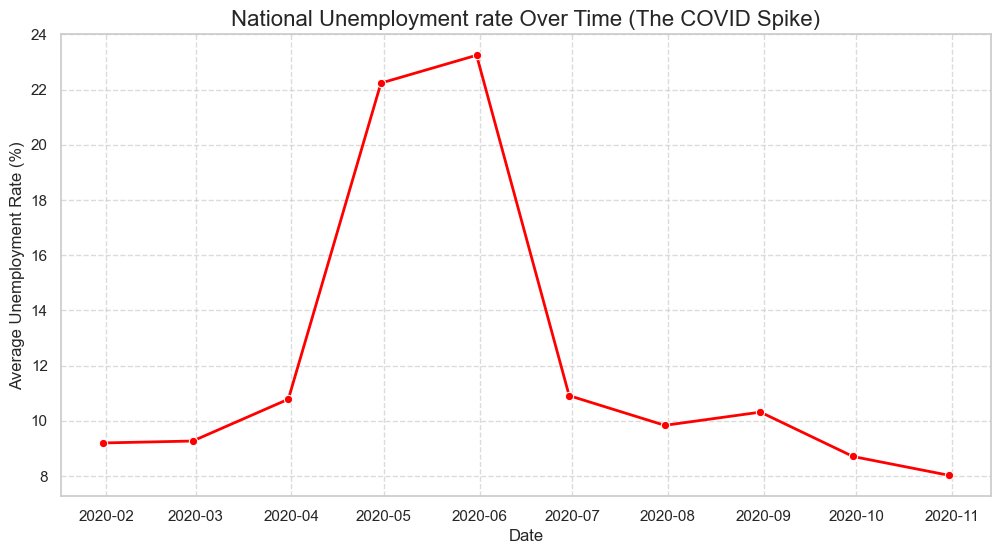

In [7]:
plt.figure(figsize=(12, 6))

# Grouped data by date-wise to see national trend
time_trend = unemp_df.groupby('Date')['Unemp_Rate'].mean().reset_index()

# Plotted the timeline
sns.lineplot(data=time_trend, x='Date', y='Unemp_Rate', color='red', marker='o', linewidth=2)

plt.title("National Unemployment rate Over Time (The COVID Spike)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Unemployment Rate (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [9]:
# interactive sunburst chart new to learn
fig = px.sunburst(
    unemp_df, 
    path=['Area', 'State'], 
    values='Unemp_Rate',
    color='Unemp_Rate', 
    color_continuous_scale='RdYlGn_r',
    title='Interactive Breakdown of Unemployment Rates (Click to Zoom.)'
)

fig.update_layout(width=800, height=800)
fig.show()